In [341]:
# importation des bibliothèques
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import GridSearchCV




In [342]:
# importation du dataset
data = pd.read_csv("orange.csv")
data

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5)
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5
...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,Orange-Red,Tangerine,Y (Scars),5.0
237,7.4,275,8.5,3.5,5.0,20,5.0,Light Orange,Minneola (Hybrid),N,4.0
238,7.5,196,15.7,3.0,3.0,13,3.0,Deep Orange,Temple,Y (Minor Insect Damage),5.0
239,7.2,251,9.8,4.3,3.0,23,1.0,Light Orange,Moro (Blood),Y (Minor Insect Damage),3.0


## I-) Analyse globale du jeu de données

In [343]:
data["Quality (1-5)"].value_counts()

,count
Quality (1-5),
4.0,76
5.0,52
4.5,29
3.0,26
3.5,23
2.0,14
2.5,12
1.0,9


In [344]:
# Le target est constitué de multiples valeurs ce qui implique que nous faisons face à un problème de classification multiples
#  dans le quel nous aimerons à partir de ces caractèristiques déterminer la qualité d'un fruit

In [345]:
data.describe()

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Quality (1-5)
count,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,7.844813,205.128631,10.907884,3.473900,3.072614,15.344398,3.599585,3.817427
std,1.086002,56.461012,2.760446,0.421007,1.323630,5.323852,1.205214,1.014410
min,6.000000,100.000000,5.500000,2.800000,1.000000,4.000000,1.000000,1.000000
25%,6.900000,155.000000,8.500000,3.200000,2.000000,11.000000,3.000000,3.000000
50%,7.800000,205.000000,11.000000,3.400000,3.000000,15.000000,4.000000,4.000000
75%,8.700000,252.000000,13.400000,3.800000,4.000000,20.000000,4.500000,4.500000
max,10.000000,300.000000,16.000000,4.400000,5.000000,25.000000,5.000000,5.000000


In [346]:
# parlons de la classe ph
# le ph minimum est de 2.8
# le ph maximum de 4.4
# les données s'éloignent de la moyenne de 0.42
# le premier quartile est de 3.2
# le deuxième quartile de 3.4
# le troisième quartile de 3.8

## II-) Nettoyage du jeu de données

#### 1-) Visualisons notre jeu de données

In [347]:
data

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5)
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5
...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,Orange-Red,Tangerine,Y (Scars),5.0
237,7.4,275,8.5,3.5,5.0,20,5.0,Light Orange,Minneola (Hybrid),N,4.0
238,7.5,196,15.7,3.0,3.0,13,3.0,Deep Orange,Temple,Y (Minor Insect Damage),5.0
239,7.2,251,9.8,4.3,3.0,23,1.0,Light Orange,Moro (Blood),Y (Minor Insect Damage),3.0


#### 2-) Visualisons le type de nos données

In [348]:
# examinons le type de données de chaque colonnes
data.dtypes

,0
Size (cm),float64
Weight (g),int64
Brix (Sweetness),float64
pH (Acidity),float64
Softness (1-5),float64
HarvestTime (days),int64
Ripeness (1-5),float64
Color,object
Variety,object
Blemishes (Y/N),object


In [349]:
# Le type de chacune de nos données est cohérent, nous n'avons pas besoin de remplacer ou de modifier un type quelconque

In [350]:
# de facons plus approfondi
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Size (cm)           241 non-null    float64
 1   Weight (g)          241 non-null    int64  
 2   Brix (Sweetness)    241 non-null    float64
 3   pH (Acidity)        241 non-null    float64
 4   Softness (1-5)      241 non-null    float64
 5   HarvestTime (days)  241 non-null    int64  
 6   Ripeness (1-5)      241 non-null    float64
 7   Color               241 non-null    object 
 8   Variety             241 non-null    object 
 9   Blemishes (Y/N)     241 non-null    object 
 10  Quality (1-5)       241 non-null    float64
dtypes: float64(6), int64(2), object(3)
memory usage: 20.8+ KB


#### 2.1) faisons un value_counts sur les données des colonnes catégorielles

In [351]:
data.Color.value_counts()

,count
Color,
Deep Orange,75
Light Orange,64
Orange-Red,55
Orange,38
Yellow-Orange,9


In [352]:
data.Variety.value_counts()

,count
Variety,
Cara Cara,21
Star Ruby,18
Temple,18
Navel,16
Moro (Blood),16
Washington Navel,14
Clementine,14
Tangerine,14
Ortanique (Hybrid),13


In [353]:
data["Blemishes (Y/N)"].value_counts()

,count
Blemishes (Y/N),
N,149
Y (Sunburn Patch),23
Y (Scars),17
Y (Minor),14
Y (Mold Spot),10
Y (Bruising),9
Y (Split Skin),8
Y (Minor Insect Damage),6
Y (Sunburn),2


In [354]:
# nous n'avons pas de na dans nos données

#### 3-) Analysons et gérons la présence des données manquantes

In [355]:
# vérifions si il y'a des données manquantes
data.isna().sum()

,0
Size (cm),0
Weight (g),0
Brix (Sweetness),0
pH (Acidity),0
Softness (1-5),0
HarvestTime (days),0
Ripeness (1-5),0
Color,0
Variety,0
Blemishes (Y/N),0


In [356]:
# nous n'avons pas de données manquantes

In [357]:
nombre_de_lignes = data.shape[0]
print(nombre_de_lignes)

241


#### 4-) Vérifions si nous avons des données dupliquées

In [358]:
data.duplicated().sum()

np.int64(0)

#### 5-) Vérifions si dans notre jeu de données il y'a une existence de corrélation entre les colonnes

In [359]:
numerical_features = ['Size (cm)', 'Weight (g)', 'Brix (Sweetness)', 'pH (Acidity)', 'Softness (1-5)', 'HarvestTime (days)', 'Ripeness (1-5)', 'Quality (1-5)']

In [360]:
# Calculate the correlation matrix
corr_matrix = data[numerical_features].corr()

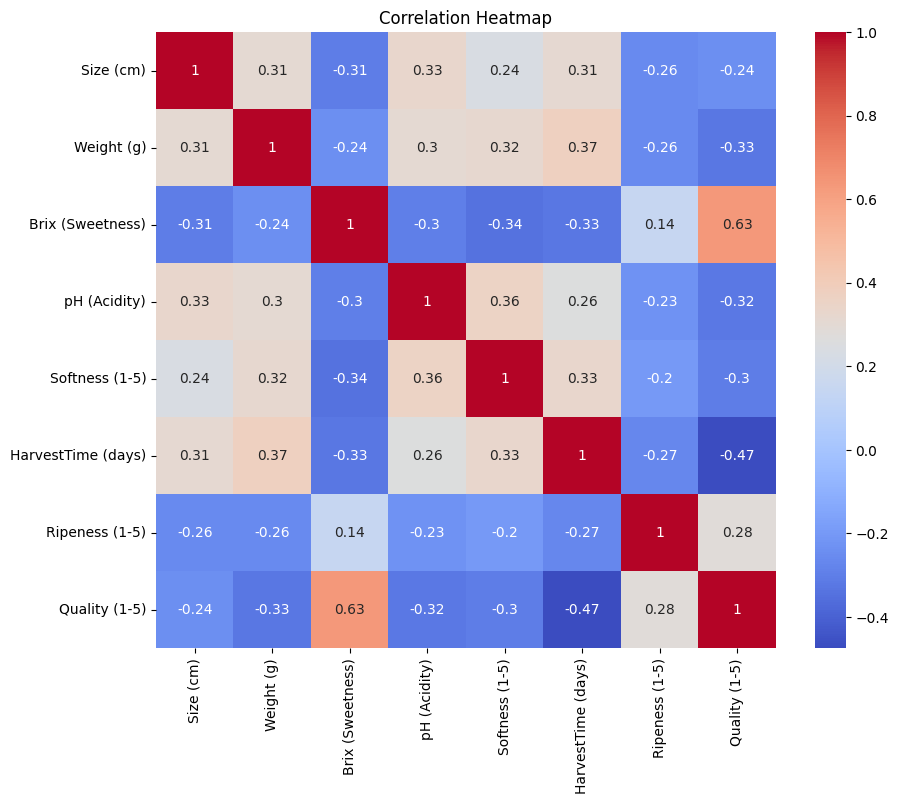

In [361]:
# Create a heatmap visualization of the correlation matrix
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [362]:
# d'après ce diagramme, nous n'avons pas vraiment de corrélation forte
# la plus grande corrélation est entre Quality et Brix
# mais pour ce cas, nous n'allons pas les supprimer car ils sont important pour notre prédiction
# nous verons plus tard avec l'utilisation du pca, si les métriques seront plus grandes ou beaucoup plus basses

#### 6-) Représentation des Boxplots et gestion des outliners

In [363]:
# boxplot sur chaque colonnes pour voir si nous avons des outliners

In [364]:
# visualisons les colonnes de notre dataset
data.columns

Index(['Size (cm)', 'Weight (g)', 'Brix (Sweetness)', 'pH (Acidity)',
       'Softness (1-5)', 'HarvestTime (days)', 'Ripeness (1-5)', 'Color',
       'Variety', 'Blemishes (Y/N)', 'Quality (1-5)'],
      dtype='object')

<Axes: ylabel='Size (cm)'>

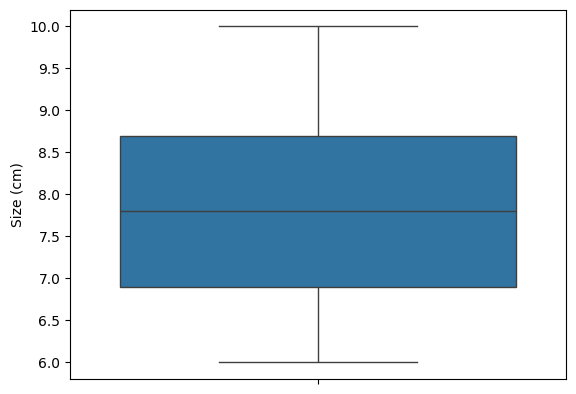

In [365]:
sns.boxplot(y="Size (cm)", data=data)

In [366]:
# la colonne size ne contient pas de outliners

<Axes: ylabel='Weight (g)'>

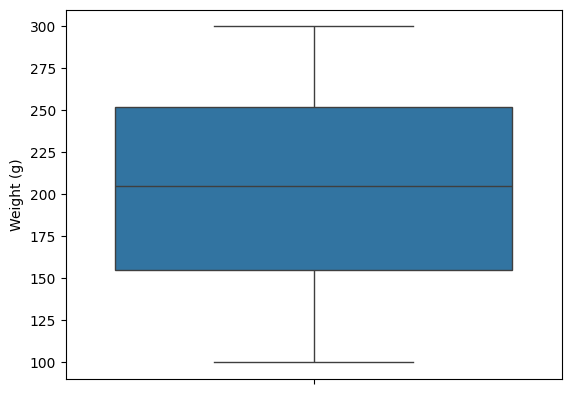

In [367]:
sns.boxplot(y="Weight (g)", data=data)

##### 6.1) Définition de la fonction Z_score qui va nous permettre de trouver les outliners sur toutes les colonnes

In [368]:
# définissons notre fonction qui nous permettra de réparer les outlines sur toutes les colonnes numériques de notre dataset
# toutes les données qui ont une valeur dupérieur à 2 fois le std sont considérés comme des outliners
def detect_outliners_zscore(data,treshold=2):
    total_length = data.shape[1] # nous définissons la taille de notre dataset en ne prenant que le nombre de colonne
    # création des tableaux vides qui contiendront plutard l'un le z_score de chaque colonne et l'autre les dataset retournés avec pour contrainte:
    # de retourner uniquement ceux dont le z_score est supérieur au treshold défini.
    t_zscrore = []
    t_dataset = []
    for i in range(0,total_length):
        z_scores = (data.iloc[:,i] - data.iloc[:,i].mean()) / data.iloc[:,i].std()
        t_zscrore.append(z_scores)
    for i in range(0,total_length):
        # np.abs permettra d'avoir des valeur positives afin de comparer au treshold qui est de 2
        t_dataset.append(data[np.abs(t_zscrore[i]) > treshold])
    return t_dataset

<Axes: ylabel='Brix (Sweetness)'>

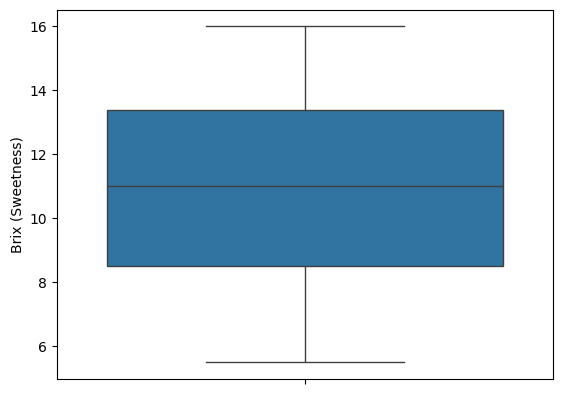

In [369]:
# boxplot sur la colonne credit_score
sns.boxplot(y="Brix (Sweetness)",data=data)

<Axes: ylabel='pH (Acidity)'>

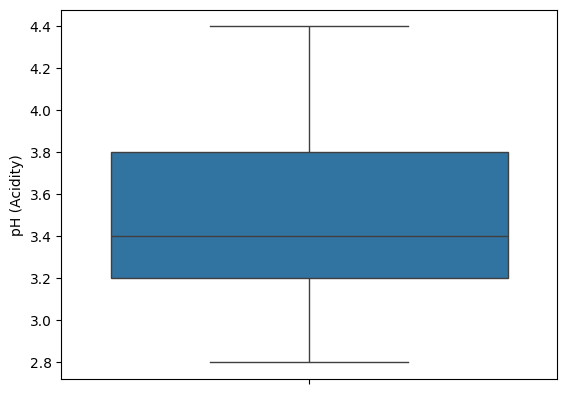

In [370]:
sns.boxplot(y="pH (Acidity)", data=data)

In [371]:
data.columns

Index(['Size (cm)', 'Weight (g)', 'Brix (Sweetness)', 'pH (Acidity)',
       'Softness (1-5)', 'HarvestTime (days)', 'Ripeness (1-5)', 'Color',
       'Variety', 'Blemishes (Y/N)', 'Quality (1-5)'],
      dtype='object')

<Axes: ylabel='Softness (1-5)'>

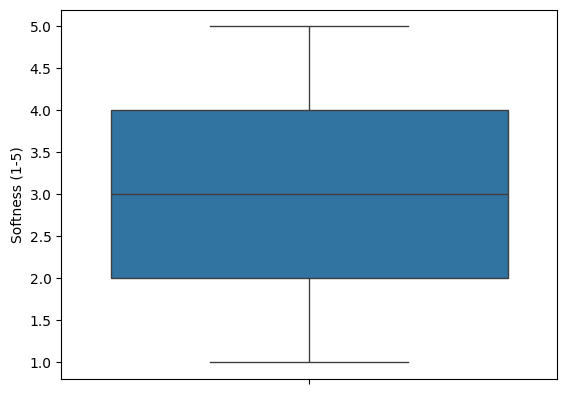

In [372]:
sns.boxplot(y="Softness (1-5)",data=data)

<Axes: ylabel='HarvestTime (days)'>

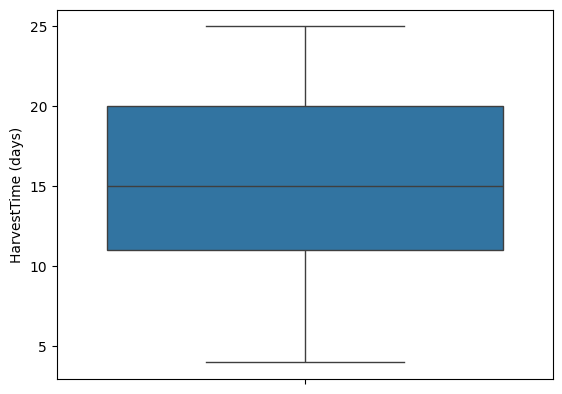

In [373]:
sns.boxplot(y="HarvestTime (days)",data=data)

<Axes: ylabel='Ripeness (1-5)'>

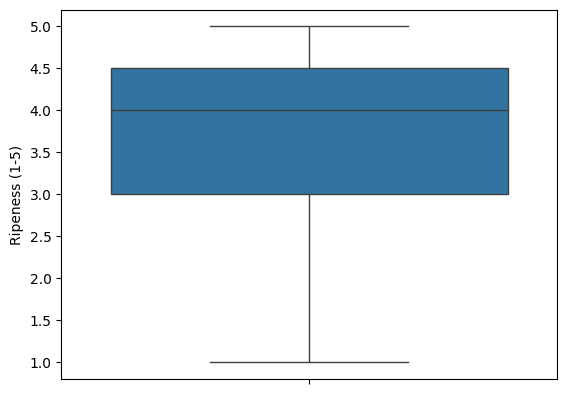

In [374]:
sns.boxplot(y="Ripeness (1-5)",data=data)

In [375]:
# nous avons terminé avec le nettoyage de nos données
# le dataset semble propre

## III-) Représentation des graphiques

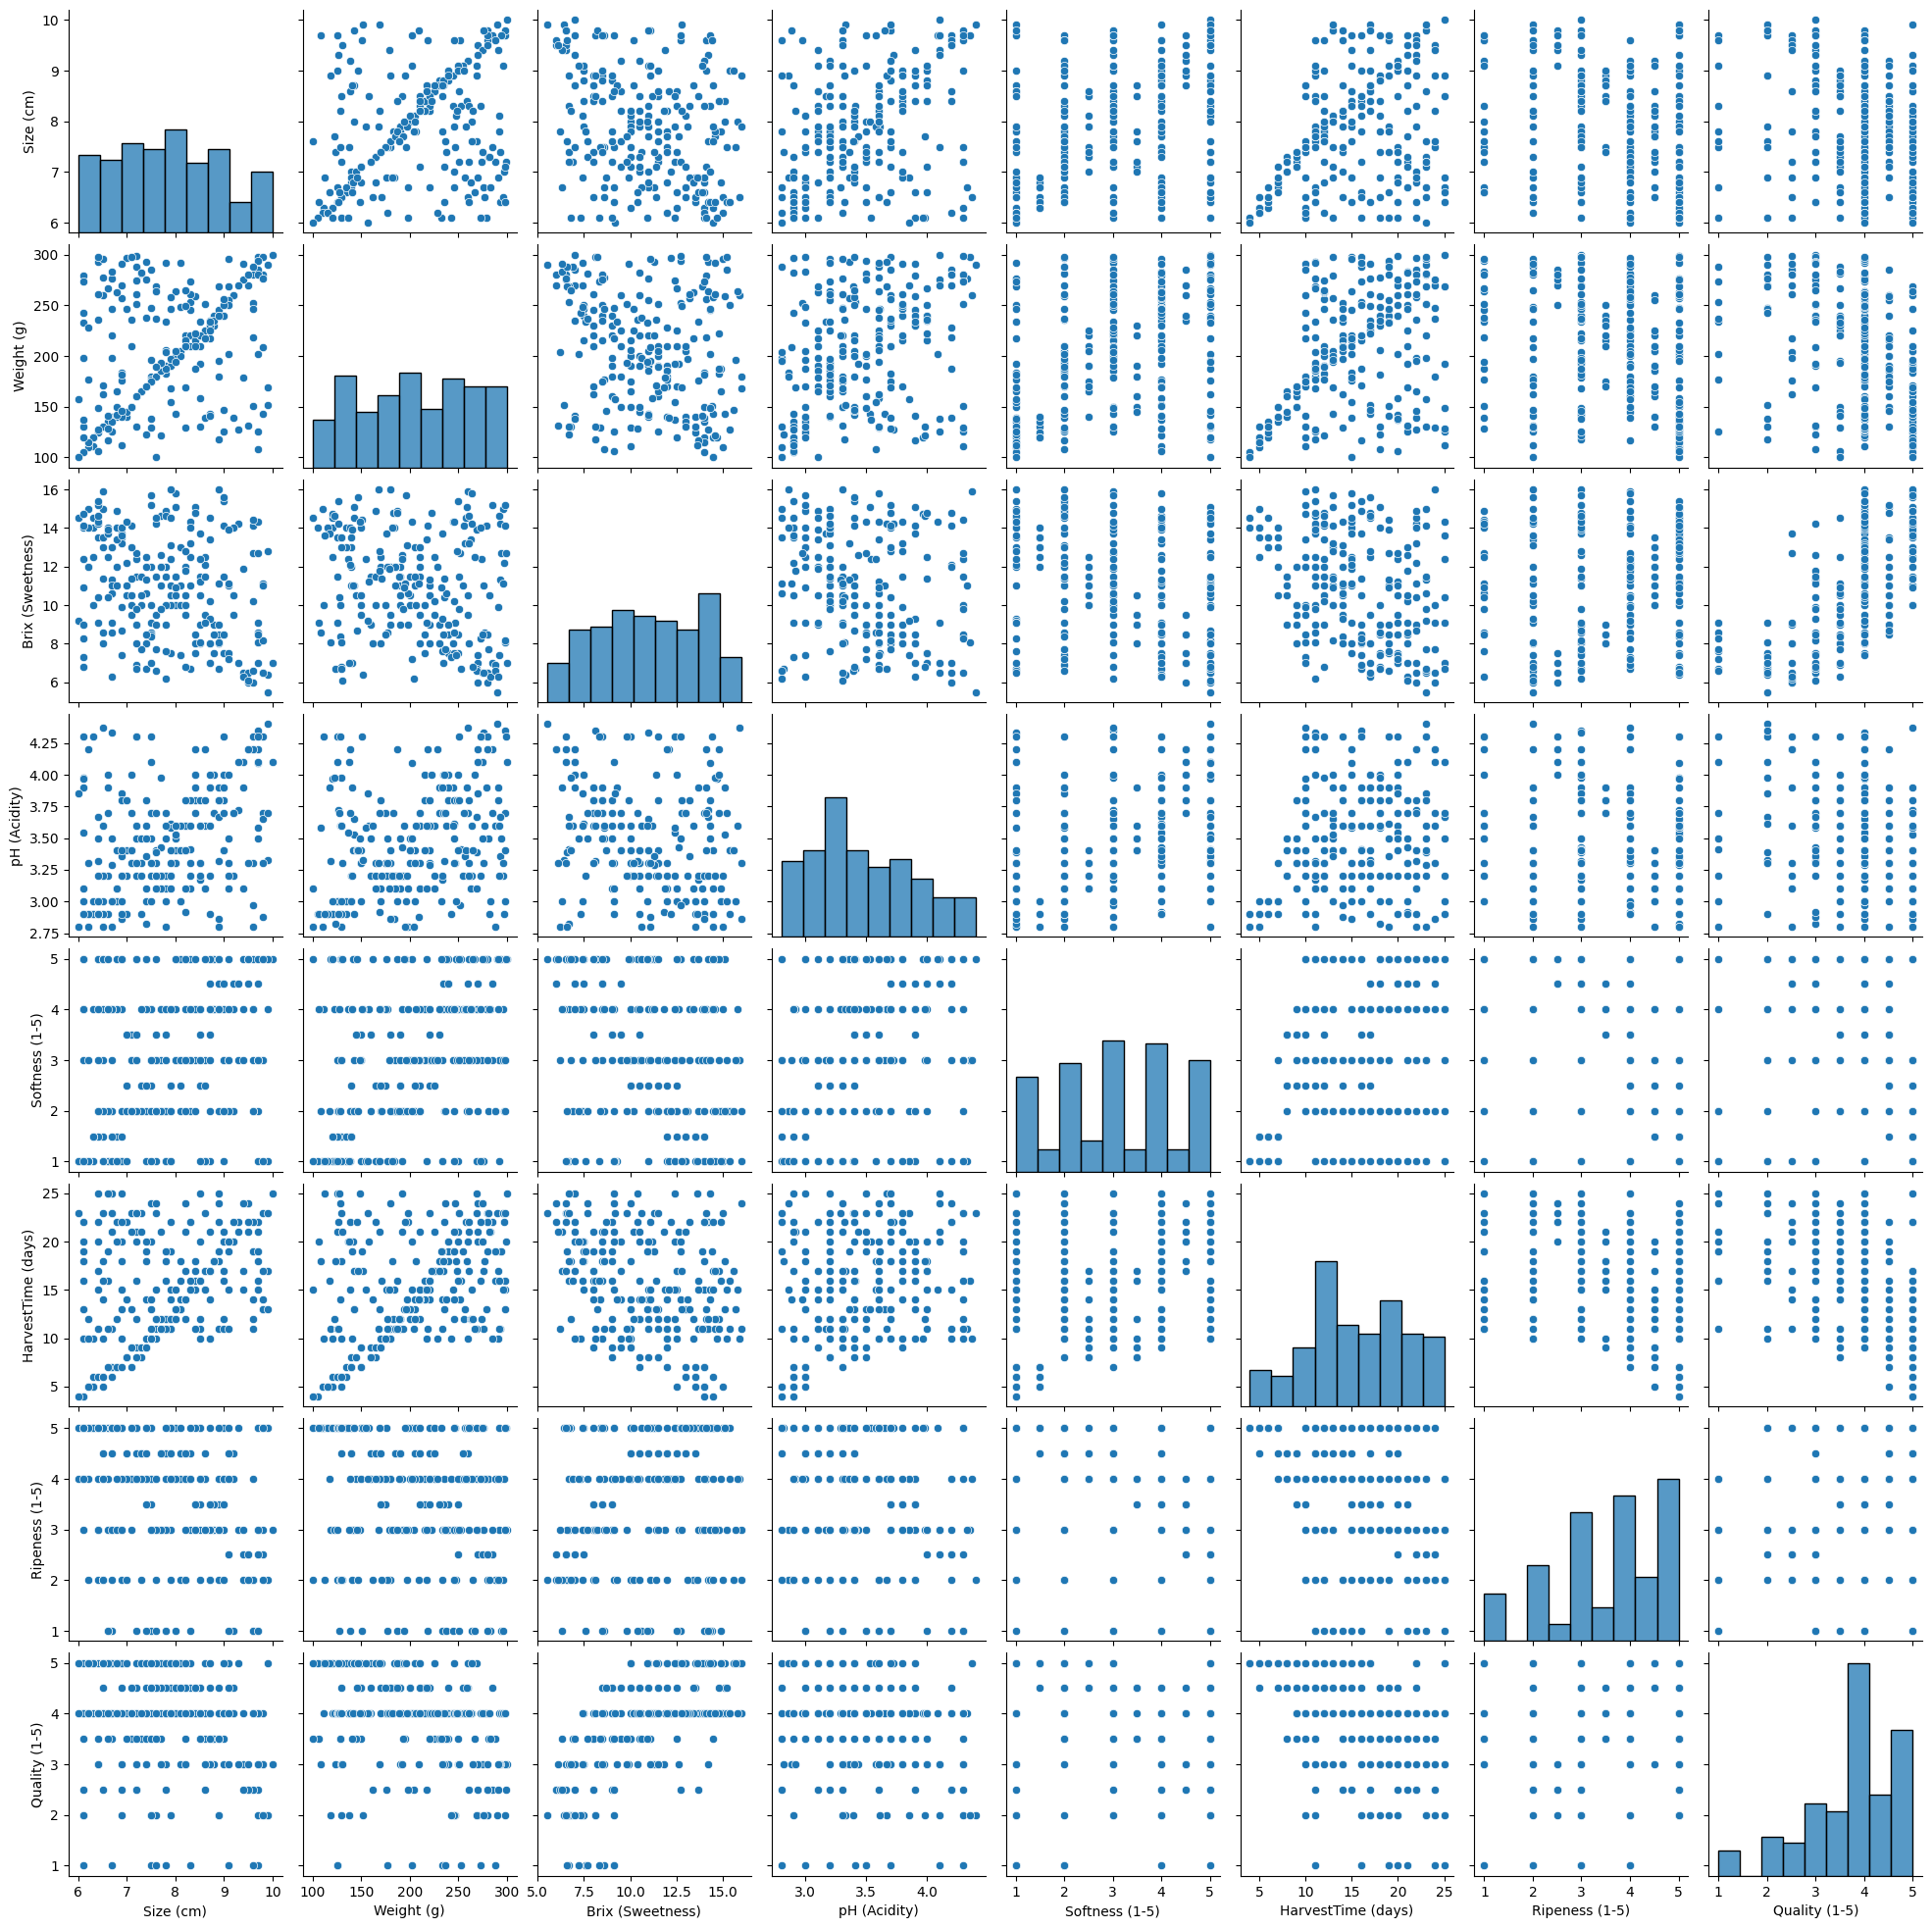

In [376]:
# faisons un paiplot
sns.pairplot(data)

In [377]:
# a ptravers ce pairplot, on observe déja à vue d'oeil deux classes formées

In [378]:
data.to_csv("orange_cleaning.csv")

## IV-) Représentation du modèle

In [379]:
data

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5)
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5
...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,Orange-Red,Tangerine,Y (Scars),5.0
237,7.4,275,8.5,3.5,5.0,20,5.0,Light Orange,Minneola (Hybrid),N,4.0
238,7.5,196,15.7,3.0,3.0,13,3.0,Deep Orange,Temple,Y (Minor Insect Damage),5.0
239,7.2,251,9.8,4.3,3.0,23,1.0,Light Orange,Moro (Blood),Y (Minor Insect Damage),3.0


In [380]:
# utilisons frequency encoder pour encoder les colonnes catégorielles
import pandas as pd

def frequency_encoding(df, columns, normalize=False, self_handle_na=True):
    df_encoded = df.copy()
    for col in columns:
        if col not in df_encoded.columns:
            print(f"Attention : La colonne '{col}' n'existe pas dans le DataFrame.")
            continue

        # Calculer les fréquences
        if self_handle_na:
            # Traiter NaN comme une catégorie distincte pour le calcul des fréquences
            frequencies = df_encoded[col].value_counts(dropna=False, normalize=normalize)
        else:
            # Ignorer les NaN pour le calcul des fréquences (les NaN originaux resteront)
            frequencies = df_encoded[col].value_counts(dropna=True, normalize=normalize)

        # Mapper les fréquences à la colonne
        # Si self_handle_na est False et qu'il y a des NaN, ils seront mappés à NaN
        # Si self_handle_na est True, les NaN originaux sont mappés à leur fréquence calculée
        df_encoded[col + '_freq_encoded'] = df_encoded[col].map(frequencies)

        # Si normalize=True et self_handle_na=False, les NaN qui n'ont pas été mappés
        # (car non inclus dans value_counts) pourraient devenir NaN. Remplacer par 0 si nécessaire.
        if normalize and not self_handle_na:
            df_encoded[col + '_freq_encoded'] = df_encoded[col + '_freq_encoded'].fillna(0)

    return df_encoded


In [381]:
categorical_cols = ['Color', 'Variety', 'Blemishes (Y/N)']
data = frequency_encoding(data, categorical_cols, normalize=False, self_handle_na=True)
print("\nDataFrame avec Encodage par Fréquence (Comptes Bruts, NaN gérés):")
data


DataFrame avec Encodage par Fréquence (Comptes Bruts, NaN gérés):


,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5),Color_freq_encoded,Variety_freq_encoded,Blemishes (Y/N)_freq_encoded
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0,38,11,149
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5,75,16,149
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0,64,21,149
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5,55,2,149
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5,38,5,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,Orange-Red,Tangerine,Y (Scars),5.0,55,14,17
237,7.4,275,8.5,3.5,5.0,20,5.0,Light Orange,Minneola (Hybrid),N,4.0,64,12,149
238,7.5,196,15.7,3.0,3.0,13,3.0,Deep Orange,Temple,Y (Minor Insect Damage),5.0,75,18,6
239,7.2,251,9.8,4.3,3.0,23,1.0,Light Orange,Moro (Blood),Y (Minor Insect Damage),3.0,64,16,6


In [382]:
data.drop(["Color","Variety","Blemishes (Y/N)"],axis=1,inplace=True)

In [383]:
data

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Quality (1-5),Color_freq_encoded,Variety_freq_encoded,Blemishes (Y/N)_freq_encoded
0,7.5,180,12.0,3.2,2.0,10,4.0,4.0,38,11,149
1,8.2,220,10.5,3.4,3.0,14,4.5,4.5,75,16,149
2,6.8,150,14.0,3.0,1.0,7,5.0,5.0,64,21,149
3,9.0,250,8.5,3.8,4.0,21,3.5,3.5,55,2,149
4,8.5,210,11.5,3.3,2.5,12,5.0,4.5,38,5,14
...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,5.0,55,14,17
237,7.4,275,8.5,3.5,5.0,20,5.0,4.0,64,12,149
238,7.5,196,15.7,3.0,3.0,13,3.0,5.0,75,18,6
239,7.2,251,9.8,4.3,3.0,23,1.0,3.0,64,16,6


#### 1) Séparons X et y

In [384]:
def impute_quality_labels(df, column_name="Quality (1-5)"):
    mapping_dict = {
        1.0: 1,
        1.5: 2,
        2.0: 2,
        2.5: 3,
        3.0: 3,
        3.5: 4,
        4.0: 4,
        4.5: 5,
        5.0: 5
    }

    # Appliquer le mapping à la colonne
    # .astype(int) assure que les nouvelles valeurs sont bien des entiers si le dictionnaire ne le fait pas déjà
    df[column_name] = df[column_name].map(mapping_dict).astype(int)

    return df

In [385]:
data[["Quality (1-5)"]]

,Quality (1-5)
0,4.0
1,4.5
2,5.0
3,3.5
4,4.5
...,...
236,5.0
237,4.0
238,5.0
239,3.0


In [386]:
impute_quality_labels(data)

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Quality (1-5),Color_freq_encoded,Variety_freq_encoded,Blemishes (Y/N)_freq_encoded
0,7.5,180,12.0,3.2,2.0,10,4.0,4,38,11,149
1,8.2,220,10.5,3.4,3.0,14,4.5,5,75,16,149
2,6.8,150,14.0,3.0,1.0,7,5.0,5,64,21,149
3,9.0,250,8.5,3.8,4.0,21,3.5,4,55,2,149
4,8.5,210,11.5,3.3,2.5,12,5.0,5,38,5,14
...,...,...,...,...,...,...,...,...,...,...,...
236,8.0,194,10.9,3.6,5.0,13,1.0,5,55,14,17
237,7.4,275,8.5,3.5,5.0,20,5.0,4,64,12,149
238,7.5,196,15.7,3.0,3.0,13,3.0,5,75,18,6
239,7.2,251,9.8,4.3,3.0,23,1.0,3,64,16,6


In [387]:
data[["Quality (1-5)"]].value_counts()

,count
Quality (1-5),
4,99
5,81
3,38
2,14
1,9


In [388]:
# je veux remplacer les valeurs de mon target Quality (1-5)pour qu'il va de 0 à 4
data["Quality (1-5)"] = data["Quality (1-5)"].replace({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})


In [389]:
data[["Quality (1-5)"]].value_counts()

,count
Quality (1-5),
3,99
4,81
2,38
1,14
0,9


In [390]:
X = data.drop(["Quality (1-5)"],axis=1).values
X

array([[  7.5, 180. ,  12. , ...,  38. ,  11. , 149. ],
       [  8.2, 220. ,  10.5, ...,  75. ,  16. , 149. ],
       [  6.8, 150. ,  14. , ...,  64. ,  21. , 149. ],
       ...,
       [  7.5, 196. ,  15.7, ...,  75. ,  18. ,   6. ],
       [  7.2, 251. ,   9.8, ...,  64. ,  16. ,   6. ],
       [  7.3, 282. ,  10.5, ...,  55. ,  11. ,  14. ]])

In [391]:
y = data[["Quality (1-5)"]].values
y

array([[3],
       [4],
       [4],
       [3],
       [4],
       [0],
       [3],
       [4],
       [2],
       [4],
       [2],
       [3],
       [4],
       [4],
       [3],
       [4],
       [3],
       [3],
       [1],
       [4],
       [2],
       [4],
       [4],
       [1],
       [4],
       [3],
       [4],
       [3],
       [0],
       [2],
       [4],
       [4],
       [4],
       [3],
       [4],
       [3],
       [4],
       [2],
       [4],
       [3],
       [4],
       [4],
       [4],
       [4],
       [4],
       [4],
       [4],
       [4],
       [2],
       [4],
       [3],
       [4],
       [4],
       [1],
       [4],
       [3],
       [4],
       [4],
       [4],
       [4],
       [4],
       [2],
       [4],
       [4],
       [3],
       [4],
       [3],
       [3],
       [2],
       [4],
       [3],
       [4],
       [4],
       [4],
       [2],
       [4],
       [3],
       [2],
       [4],
       [3],
       [2],
       [4],
       [3],
    

In [392]:
data.columns

Index(['Size (cm)', 'Weight (g)', 'Brix (Sweetness)', 'pH (Acidity)',
       'Softness (1-5)', 'HarvestTime (days)', 'Ripeness (1-5)',
       'Quality (1-5)', 'Color_freq_encoded', 'Variety_freq_encoded',
       'Blemishes (Y/N)_freq_encoded'],
      dtype='object')

#### 2-) Séparons les données du train et du test

In [393]:
# je sépare X_train et y_train à l'aide du modèle train_test_split de scikit learn
X_train, X_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=123)

#### Standardisons notre modèle

In [394]:
Sc = StandardScaler()
X_train = Sc.fit_transform(X_train)
#X_trainIverse = Sc.inverse_transform(X_train)
X_test = Sc.transform(X_test)

#### 3-) Entrainons notre modèle

In [395]:
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state=0)
classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

#### 4-) déterminons le y_predict et déterminons le accuracy

In [396]:
# on prédit notre y_train à partir de notre x_train et on calcule accuracy
y_train_prediction = classifier.predict(X_train)
acc = accuracy_score(y_train, y_train_prediction)
acc

1.0

#### 5) Affichons le classification report qui contient nos métriques

In [397]:
print(classification_report(y_train, y_train_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        28
           3       1.00      1.00      1.00        76
           4       1.00      1.00      1.00        59

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



<Axes: >

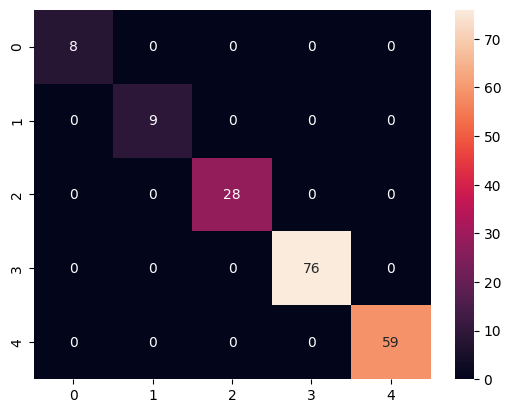

In [398]:
conf= confusion_matrix(y_train,y_train_prediction)
sns.heatmap(conf,annot=True)

#### 5.1) Faisons un cross validation pendant le training

In [399]:
#KFold: nombre de coupure, nous avons un dataset de plus de 20000 données nous allons choisir une segmentation ou coupure de 20 segment
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator=classifier, X=X_train, y=y_train, cv=20)
print("Cross Val Accuracy", (accuracies))

Cross Val Accuracy [0.44444444 0.66666667 0.55555556 0.44444444 0.66666667 0.44444444
 0.44444444 0.77777778 0.44444444 0.44444444 0.66666667 0.55555556
 0.77777778 0.44444444 0.55555556 0.33333333 0.55555556 0.44444444
 0.55555556 0.33333333]


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=20.
  warnings.warn(


#### 6) testons notre modèle et affichons le accuracy

In [400]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_test_prediction = classifier.predict(X_test)
accTest = accuracy_score(y_test, y_test_prediction)
accTest

0.47540983606557374

In [401]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_prediction))
# plus le f1_score est élevée mieux c'est

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.33      0.20      0.25         5
           2       0.43      0.60      0.50        10
           3       0.44      0.35      0.39        23
           4       0.58      0.64      0.61        22

    accuracy                           0.48        61
   macro avg       0.36      0.36      0.35        61
weighted avg       0.48      0.48      0.47        61



<Axes: >

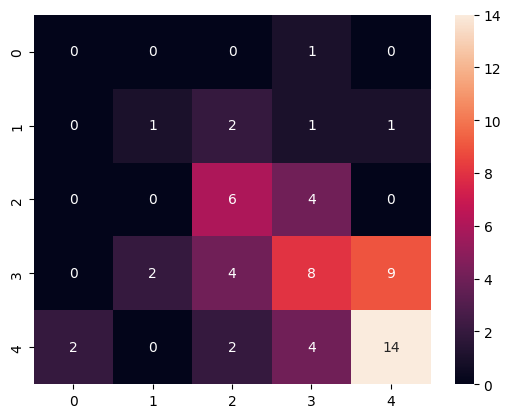

In [402]:
conf= confusion_matrix(y_test,y_test_prediction)
sns.heatmap(conf,annot=True)

### 6.1) Faisons un Cross Validation afin de voir comment le test c'est passé

In [403]:
#KFold: nombre de coupure, nous avons un dataset de plus de 20000 données nous allons choisir une segmentation ou coupure de 20 segment
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator=classifier, X=X_test, y=y_test, cv=20)
print("Cross Val Accuracy", (accuracies))

Cross Val Accuracy [0.5        0.         0.66666667 0.66666667 1.         0.
 0.33333333 0.33333333 0.33333333 0.33333333 1.         0.33333333
 0.33333333 0.33333333 0.66666667 0.33333333 1.         0.66666667
 0.66666667 0.66666667]


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=20.
  warnings.warn(


In [404]:
# optimisons le decision tree avec les paramètres
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': [None, 'auto', 'sqrt', 'log2', 0.6, 0.8, 1.0],
}


In [405]:
grid_search = GridSearchCV(estimator=classifier,
                           param_grid=param_grid,
                           scoring='f1_weighted', # Or 'f1_weighted', 'accuracy', etc. based on your problem
                           cv=5,              # Number of cross-validation folds
                           n_jobs=-1,         # Use all available CPU cores
                           verbose=1)         # Show progress

# Fit the grid search to your data
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 490 candidates, totalling 2450 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
350 fits failed out of a total of 2450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
176 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/uti

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(criterion='entropy',
                                              random_state=0),
             n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 15, 20, 25, 30],
                         'max_features': [None, 'auto', 'sqrt', 'log2', 0.6,
                                          0.8, 1.0],
                         'min_samples_leaf': [1, 2, 5, 10, 20]},
             scoring='f1_weighted', verbose=1)

In [406]:
# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best ROC AUC score: ", grid_search.best_score_)

# Get the best model
best_dt_model = grid_search.best_estimator_

Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 10}
Best ROC AUC score:  0.555575436053697


In [407]:
classifierOptimised = DecisionTreeClassifier(criterion = 'gini',max_depth=5,max_features=0.6,min_samples_leaf=5, random_state=0)
classifierOptimised.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, max_features=0.6, min_samples_leaf=5,
                       random_state=0)

In [408]:
# on prédit notre y_train à partir de notre x_train et on calcule accuracy
from sklearn.metrics import accuracy_score, confusion_matrix
y_train_prediction = classifierOptimised.predict(X_train)
acc = accuracy_score(y_train, y_train_prediction)
acc

0.7166666666666667

In [409]:
# on calcule les métriques
from sklearn.metrics import classification_report
print(classification_report(y_train, y_train_prediction))

              precision    recall  f1-score   support

           0       0.40      0.25      0.31         8
           1       0.67      0.67      0.67         9
           2       0.72      0.46      0.57        28
           3       0.78      0.74      0.76        76
           4       0.68      0.88      0.77        59

    accuracy                           0.72       180
   macro avg       0.65      0.60      0.61       180
weighted avg       0.72      0.72      0.71       180



In [410]:
# on prédit notre y_test avec le X_test qu'on avait
from sklearn.metrics import accuracy_score, confusion_matrix
y_test_prediction = classifierOptimised.predict(X_test)
accTest = accuracy_score(y_test, y_test_prediction)
accTest

0.5573770491803278

In [411]:
# on calcule les métriques pour le test
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_prediction))
# plus le f1_score est élevée mieux c'est

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      0.40      0.44         5
           2       0.60      0.60      0.60        10
           3       0.50      0.35      0.41        23
           4       0.58      0.82      0.68        22

    accuracy                           0.56        61
   macro avg       0.44      0.43      0.43        61
weighted avg       0.54      0.56      0.53        61



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## XGBOOST

In [412]:
y_train = y_train.ravel()
y_test = y_test.ravel()

In [413]:
D_Train = xgb.DMatrix(X_train, label=y_train)
D_Test = xgb.DMatrix(X_test, label=y_test)

In [414]:
num_classes = 5 # REPLACE THIS WITH YOUR ACTUAL NUMBER OF CLASSES!

param = {
    'max_depth':3,
    'eta':0.3,
    'objective':'multi:softprob',
    'num_class': num_classes
}

In [415]:
steps = 20
model = xgb.train(param, D_Train, steps)


In [416]:
#Matrice de Confusion
pred_train = model.predict(D_Train)
pred_test = model.predict(D_Test)

best_pred_train = np.asarray([np.argmax(line) for line in pred_train])
best_pred_test = np.asarray([np.argmax(line) for line in pred_test])

print(f"Accuracy Score Train : {accuracy_score(y_train, best_pred_train)}")
print(f"Accracy Score Test : {accuracy_score(y_test, best_pred_test)}")

Accuracy Score Train : 0.9666666666666667
Accracy Score Test : 0.6229508196721312


<Axes: >

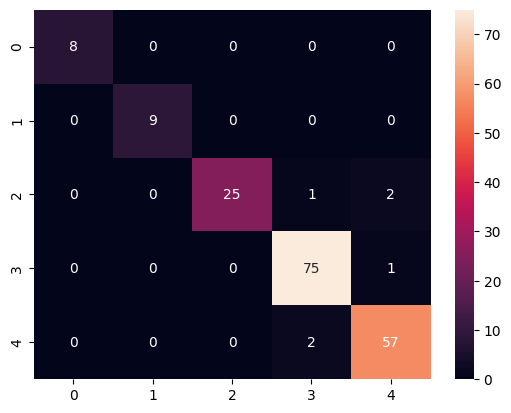

In [417]:
cmt = confusion_matrix(y_train, best_pred_train)
sns.heatmap(cmt, annot=True)

In [418]:
print(classification_report(y_train, best_pred_train))
print(classification_report(y_test, best_pred_test))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         9
           2       1.00      0.89      0.94        28
           3       0.96      0.99      0.97        76
           4       0.95      0.97      0.96        59

    accuracy                           0.97       180
   macro avg       0.98      0.97      0.98       180
weighted avg       0.97      0.97      0.97       180

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         5
           2       0.40      0.60      0.48        10
           3       0.59      0.70      0.64        23
           4       0.84      0.73      0.78        22

    accuracy                           0.62        61
   macro avg       0.37      0.40      0.38        61
weighted avg       0.59      0.62      0.60        61



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [419]:
# le meilleur modèle est le xgboost exportons ce modèle avec pickle
import pickle
with open('xgboost_model.pkl', 'wb') as file:
    pickle.dump(model, file)